# Practical Task: Agents, MCP

---

## Task Overview

This notebook demonstrates a production-style **AI agent** built with the Anthropic Claude API and the **Model Context Protocol (MCP)** pattern.
The agent answers natural-language questions about real-time weather and current news by autonomously selecting and invoking the right tools.

### What this notebook demonstrates

| Layer | What is shown |
|-------|---------------|
| **MCP Server 1 — Weather** | Custom FastMCP server wrapping the free Open-Meteo REST API; geocoding via a built-in city dictionary + Open-Meteo geocoding |
| **MCP Server 2 — News** | Integration of the `news-aggregator-mcp-server` pip package (RSS/Atom, HackerNews Firebase API, GDELT global news) |
| **Agent Orchestrator** | Agentic tool-use loop with Claude claude-opus-4-6: `while stop_reason == "tool_use"` → execute tool → append result → re-prompt |
| **Streamlit UI** | Conversational chat interface + evaluation panel with radar/bar charts |
| **Evaluation Framework** | LLM-as-judge (Claude Haiku 4.5) scoring 4 metrics; keyword coverage; composite pass/fail per question |

---

## Methodology

The project follows the **MCP (Model Context Protocol)** pattern: tools are defined with structured JSON schemas and registered with the Claude API.
The model decides autonomously which tool to call, with what arguments, and when to stop.

```
User question
      │
      ▼
claude-opus-4-6  ──tool_use──►  _execute_tool(name, input)
      ▲                              │
      │◄──── tool_result ────────────┘
      │                          (repeat up to 10 iterations)
      └──end_turn──► Final answer returned to user
```

**Evaluation methodology:** Each agent response is scored by a second model (Claude Haiku 4.5, used as a cheap, fast judge) on three criteria — relevance, groundedness, and completeness — plus deterministic keyword-coverage matching. A weighted composite score determines pass/fail against a per-question threshold.

### References

| Resource | URL |
|----------|-----|
| Anthropic Claude API docs | https://docs.anthropic.com |
| Model Context Protocol spec | https://modelcontextprotocol.io |
| Open-Meteo (weather API) | https://open-meteo.com |
| news-aggregator-mcp-server (PyPI) | https://pypi.org/project/news-aggregator-mcp-server |
| HackerNews Firebase API | https://hacker-news.firebaseio.com |
| GDELT Project | https://gdeltproject.org |
| Anthropic Tool Use guide | https://docs.anthropic.com/en/docs/build-with-claude/tool-use |

### Data and relevant resources used

- **Weather data** — Open-Meteo REST API (no API key required, free tier, global coverage)
- **RSS/Atom feeds** — 19 predefined sources across 6 categories: TechCrunch, Wired, BBC News, Reuters, Bloomberg Technology, CoinDesk, Nature, IEEE Spectrum, MIT Technology Review, Financial Times, CNBC, and more
- **HackerNews** — Public Firebase REST API (top/new/best/ask/show/jobs stories)
- **GDELT Project** — Global news intelligence database covering 65+ languages and 100+ countries
- **Evaluation dataset** — 10 hand-crafted questions across 5 categories: `weather`, `news_rss`, `news_hackernews`, `news_gdelt`, `mixed`, `edge`
- **Judge model** — `claude-haiku-4-5` (Anthropic, cost-efficient evaluation)

### Installation steps

```bash
# 1. Clone or unzip the project
cd mcp_agents_epam

# 2. Install all dependencies
pip install -r requirements.txt

# 3. Configure your Anthropic API key
cp .env.example .env
# Edit .env and set:  ANTHROPIC_API_KEY=sk-ant-...

# 4. Run the notebook
jupyter notebook notebook.ipynb

# 4b. Or run the Streamlit app instead
streamlit run app.py
```

> **Note:** All data sources (Open-Meteo, HackerNews, GDELT, RSS feeds) are free and require no additional API keys.
Only the Anthropic API key is needed.

### Other notes

- The `news-aggregator-mcp-server` package uses **German field names** internally (`titel`, `zusammenfassung`, `punkte`, etc.).
  All display code in this notebook maps them to English column names.
- GDELT may enforce rate limits (HTTP 429). The notebook retries with exponential backoff (5 s → 10 s → 20 s).
- The async internals of the news package are bridged to synchronous calls via a `_run()` helper that uses a `ThreadPoolExecutor` fallback when a running event loop is detected (required for Streamlit and Jupyter compatibility).
- Running the full evaluation suite (~40 API calls) costs approximately **$0.05–0.15 USD** with Claude Opus 4.6 + Haiku 4.5.

---

## Architecture

```
┌─────────────┐   questions   ┌──────────────────────┐
│  Streamlit  │ ────────────► │  WeatherNewsAgent    │
│   app.py    │ ◄──────────── │  (orchestrator.py)   │
└─────────────┘   answers     └──────────┬───────────┘
                                         │ tool_use loop
                          ┌──────────────┼──────────────┐
                          ▼              ▼              ▼
                   ┌────────────┐ ┌──────────┐ ┌──────────────┐
                   │ Open-Meteo │ │   RSS    │ │ HackerNews / │
                   │  (custom   │ │  feeds   │ │   GDELT      │
                   │ MCP server)│ │(pip MCP) │ │  (pip MCP)   │
                   └────────────┘ └──────────┘ └──────────────┘
```

---

## Table of Contents
1. [Setup & API Key](#1-setup)
2. [MCP Server 1 — Weather (Open-Meteo)](#2-weather)
3. [MCP Server 2 — News Aggregator](#3-news)
4. [Agent Orchestrator](#4-orchestrator)
5. [Example Queries](#5-queries)
6. [Evaluation Framework](#6-evaluation)
7. [Results Visualisation](#7-visualisation)
8. [Summary & Key Learnings](#8-summary)


---
## 1. Setup & API Key <a id="1-setup"></a>

Install all dependencies (skip if already installed) and configure the Anthropic API key.

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
# Uncomment the next line on first run
!pip install -q anthropic streamlit httpx feedparser mcp news-aggregator-mcp-server python-dotenv pandas plotly
print("Dependencies ready.")

Dependencies ready.


In [2]:
import os
import sys
import json
import asyncio
from pathlib import Path

# ── Add project root to sys.path so local modules are importable ──────────────
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version}")

Project root: /Users/Denise_Mendez/Documents/mcp_agents_epam
Python: 3.14.3 (v3.14.3:323c59a5e34, Feb  3 2026, 11:41:37) [Clang 16.0.0 (clang-1600.0.26.6)]


In [3]:
# ── API Key ───────────────────────────────────────────────────────────────────
# Loads ANTHROPIC_API_KEY automatically from the .env file in the project root.
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / ".env")  # reads .env into os.environ

API_KEY = os.environ.get("ANTHROPIC_API_KEY", "")
if not API_KEY:
    raise EnvironmentError(
        "ANTHROPIC_API_KEY not found. "
        "Ensure .env exists in the project root with: ANTHROPIC_API_KEY=sk-ant-..."
    )
print(f"API key loaded from .env: sk-ant-...{API_KEY[-4:]}")

API key loaded from .env: sk-ant-...lwAA


---
## 2. MCP Server 1 — Weather (Open-Meteo) <a id="2-weather"></a>

The custom MCP server wraps two functions:
- **`resolve_location(city_name)`** — geocodes a city name to lat/lon using a built-in dictionary + Open-Meteo geocoding API.
- **`get_current_weather(latitude, longitude)`** — fetches live weather from [api.open-meteo.com](https://api.open-meteo.com) (no API key required).

### 2.1 Architecture of the weather MCP server

```
weather_server.py          weather_tools.py
┌───────────────────┐      ┌──────────────────────────────┐
│ @mcp.tool()       │      │ resolve_location(city) → dict │
│ get_weather(...)  │─────►│   KNOWN_CITIES dict (12 cities│
│                   │      │   + Open-Meteo geocoding API) │
│ @mcp.tool()       │      ├──────────────────────────────┤
│ resolve_city(...) │─────►│ get_current_weather(lat, lon) │
└───────────────────┘      │   api.open-meteo.com/v1/...  │
  stdio transport           │   WMO weather code mapping   │
                            └──────────────────────────────┘
```

In [4]:
from mcp_servers.weather_tools import get_current_weather, resolve_location

# ── 2.2 Demo: resolve a city name ─────────────────────────────────────────────
city_info = resolve_location("bogota")
print("Resolved city:")
print(json.dumps(city_info, indent=2))

Resolved city:
{
  "lat": 4.71,
  "lon": -74.07,
  "label": "Bogot\u00e1, Colombia"
}


In [5]:
# ── 2.3 Demo: fetch live weather ──────────────────────────────────────────────
weather = get_current_weather(
    latitude=city_info["lat"],
    longitude=city_info["lon"],
    location_name=city_info["label"],
)
print("Live weather data:")
print(json.dumps(weather, indent=2, ensure_ascii=False))

Live weather data:
{
  "location": "Bogotá, Colombia",
  "latitude": 4.71,
  "longitude": -74.07,
  "temperature_celsius": 14.7,
  "feels_like_celsius": 12.7,
  "humidity_percent": 75,
  "windspeed_kmh": 4.8,
  "wind_direction_degrees": 228,
  "weather_condition": "Slight rain showers",
  "weather_code": 80,
  "is_day": true,
  "observation_time": "2026-04-06T17:45",
  "timezone": "America/Bogota",
  "source": "Open-Meteo (https://open-meteo.com)"
}


In [6]:
# ── 2.4 Test multiple cities ──────────────────────────────────────────────────
test_cities = ["london", "tokyo", "new york", "sydney"]

for city in test_cities:
    info = resolve_location(city)
    if info:
        w = get_current_weather(info["lat"], info["lon"], info["label"])
        print(f"{w.get('location', city):20s} → {w.get('temperature_celsius', '?')}°C  "
              f"💨 {w.get('windspeed_kmh', '?')} km/h  "
              f"{w.get('weather_condition', '')}")
    else:
        print(f"{city:20s} → not found")

London, UK           → 11.1°C  💨 10.4 km/h  Clear sky
Tokyo, Japan         → 17.0°C  💨 9.9 km/h  Overcast
New York, USA        → 12.6°C  💨 15.8 km/h  Overcast
Sydney, Australia    → 17.3°C  💨 4.7 km/h  Clear sky


---
## 3. MCP Server 2 — News Aggregator <a id="3-news"></a>

We use the `news-aggregator-mcp-server` pip package which provides **three data sources** with no API keys:

| Source | Tools | What it covers |
|--------|-------|----------------|
| RSS/Atom | `get_news_by_category`, `search_rss_feeds`, `fetch_feed`, `list_feed_catalog` | 19 feeds: TechCrunch, Wired, BBC, Reuters, Bloomberg, CoinDesk, Nature, … |
| HackerNews | `get_hackernews_top`, `get_hackernews_story`, `get_hackernews_trending` | Firebase API — tech/startup stories |
| GDELT | `search_global_news`, `get_news_by_country`, `get_news_timeline`, `get_trending_topics` | 65+ languages, 100+ countries |

The `news_mcp_client.py` module bridges the package's **async** internals to the synchronous call context of Streamlit and the notebook.

In [7]:
from mcp_servers.news_mcp_client import ALL_NEWS_TOOLS

print(f"Available news tools ({len(ALL_NEWS_TOOLS)}):")
for name in ALL_NEWS_TOOLS:
    print(f"  • {name}")

Available news tools (11):
  • fetch_feed
  • get_news_by_category
  • search_rss_feeds
  • list_feed_catalog
  • get_hackernews_top
  • get_hackernews_story
  • get_hackernews_trending
  • search_global_news
  • get_news_timeline
  • get_news_by_country
  • get_trending_topics


In [8]:
# ── 3.1 RSS: top technology headlines ─────────────────────────────────────────
import pandas as pd

tech_news = ALL_NEWS_TOOLS["get_news_by_category"](category="tech", max_per_feed=2)

articles = tech_news if isinstance(tech_news, list) else tech_news.get("articles", [])

rows = []
for item in articles[:10]:
    rows.append({
        "Source":    item.get("source", "?"),
        "Title":     item.get("title", "?"),
        "Author":    item.get("author", ""),
        "Published": item.get("published", "")[:16],
        "Summary":   item.get("summary") or "",
    })

df_rss = pd.DataFrame(rows)
print(f"Top Tech Headlines (RSS) — {len(articles)} articles fetched\n")

pd.set_option("display.max_colwidth", None)
df_rss.style.set_properties(
    subset=["Title", "Summary"],
    **{"white-space": "normal", "max-width": "500px", "text-align": "left"}
).set_properties(
    subset=["Source", "Author", "Published"],
    **{"white-space": "nowrap"}
)

Top Tech Headlines (RSS) — 8 articles fetched



,Source,Title,Author,Published,Summary
0,TechCrunch,"OpenAI alums have been quietly investing from a new, potentially $100M fund",Julie Bort,"Mon, 06 Apr 2026","Zero Shot, a new venture capital fund with deep ties to OpenAI, is aiming to raise $100 million for its first fund. It has already written some checks."
1,TechCrunch,Gas prices aren’t the only factor fueling used EV sales,Kirsten Korosec,"Mon, 06 Apr 2026",The most recent electric vehicle sales data provided a grim picture — at least for new EVs. Used EVs are moving in the opposite direction.
2,Wired,A Single Strike Won’t Shut Off the Gulf’s Desalination System,Dana Alomar,"Mon, 06 Apr 2026","The Gulf’s water system is built with layers of backup, but it relies on continuous operation to hold."
3,Wired,Border Patrol Agents Sold Challenge Coins With ‘Charlotte’s Web’ Characters in Riot Gear,Maddy Varner,"Mon, 06 Apr 2026","Nonprofits run out of US Border Patrol stations are also selling other “operation”-themed coins that include a phrase popularized by the Proud Boys, potentially in violation of government rules."
4,Ars Technica,"Sports bets on prediction markets ruled to be ""swaps,"" exempt from state laws",Jon Brodkin,"Mon, 06 Apr 2026",Court rules US preempts states from applying gambling laws to prediction markets.
5,Ars Technica,Trump's next budget once again calls for massive cuts to science,John Timmer,"Mon, 06 Apr 2026","Congress rejected huge cuts to science in 2026, but Trump is trying again."
6,The Verge,Wisconsin governor says ‘no’ to age checks for porn,Emma Roth,2026-04-06T17:47,"Wisconsin Gov. Tony Evers vetoed a bill that would've required residents to verify their age before accessing porn sites, as reported earlier by 404 Media. In a letter to the members of the assembly last week, Evers writes that the bill ""imposes an intrusive burden on adults who are trying to access constitutionally protected materials."" […]"
7,The Verge,"Artemis II astronauts break a record, name a crater",Stevie Bonifield,2026-04-06T16:40,"A few minutes before 2PM ET on Monday, the crew of Artemis II broke a record set 56 years ago by the ill-fated Apollo 13 mission - at over 248,655 miles, they have now traveled farther from Earth than any humans before them. They marked the occasion with a crater naming ceremony that left the […]"


In [9]:
# ── 3.2 HackerNews: top stories ───────────────────────────────────────────────
import pandas as pd
from datetime import datetime, timezone
from IPython.display import display, HTML

hn_stories = ALL_NEWS_TOOLS["get_hackernews_top"](story_type="top", limit=10)
stories = hn_stories if isinstance(hn_stories, list) else hn_stories.get("stories", [])

rows = []
for s in stories[:10]:
    ts = s.get("published_unix")
    date_str = datetime.fromtimestamp(ts, tz=timezone.utc).strftime("%Y-%m-%d %H:%M") if ts else ""
    url = s.get("url", "")
    hn_link = s.get("hn_link", "")
    rows.append({
        "Title":      s.get("title", "?"),
        "Points":     s.get("points", 0),
        "Comments":   s.get("comments", 0),
        "Author":     s.get("author", ""),
        "Published":  date_str,
        "Article":    f'<a href="{url}" target="_blank">open</a>' if url else "",
        "Discussion": f'<a href="{hn_link}" target="_blank">HN</a>' if hn_link else "",
    })

df_hn = pd.DataFrame(rows)
print(f"Top Hacker News Stories — {len(stories)} fetched")
print("(HN external-link stories have no article summary — click 'open' to read the full article)\n")

html_table = df_hn.to_html(escape=False, index=False)

styled_html = f"""
<style>
  .hn-table {{
      width: 100%;
      border-collapse: collapse;
      font-size: 13px;
  }}
  .hn-table th {{
      text-align: left;
      padding: 8px 10px;
      border-bottom: 2px solid #ccc;
      white-space: nowrap;
      background: #f5f5f5;
  }}
  .hn-table td {{
      padding: 7px 10px;
      border-bottom: 1px solid #eee;
      vertical-align: top;
      word-wrap: break-word;
      white-space: normal;
  }}
  .hn-table td:nth-child(1) {{ max-width: 380px; }}
  .hn-table td:nth-child(2),
  .hn-table td:nth-child(3) {{ text-align: right; white-space: nowrap; }}
  .hn-table td:nth-child(4),
  .hn-table td:nth-child(5) {{ white-space: nowrap; }}
  .hn-table td:nth-child(6),
  .hn-table td:nth-child(7) {{ text-align: center; white-space: nowrap; }}
</style>
{html_table.replace('<table', '<table class="hn-table"')}
"""

display(HTML(styled_html))

Top Hacker News Stories — 10 fetched
(HN external-link stories have no article summary — click 'open' to read the full article)



Title,Points,Comments,Author,Published,Article,Discussion
Show HN: Ghost Pepper – Local hold-to-talk speech-to-text for macOS,150,68,MattHart88,2026-04-06 19:50,open,HN
Launch HN: Freestyle – Sandboxes for Coding Agents,173,99,benswerd,2026-04-06 16:32,open,HN
A cryptography engineer's perspective on quantum computing timelines,265,110,thadt,2026-04-06 15:31,open,HN
Show HN: GovAuctions lets you browse government auctions at once,168,56,player_piano,2026-04-06 16:21,open,HN
German police name alleged leaders of GandCrab and REvil ransomware groups,243,127,Bender,2026-04-06 13:52,open,HN
"Show HN: Hippo, biologically inspired memory for AI agents",15,6,kitfunso,2026-04-06 21:49,open,HN
What being ripped off taught me,300,167,doctorhandshake,2026-04-06 12:53,open,HN
Book review: There Is No Antimemetics Division,184,130,ibobev,2026-04-06 13:44,open,HN
Sam Altman may control our future – can he be trusted?,441,135,adrianhon,2026-04-06 10:36,open,HN
HackerRank (YC S11) Is Hiring,1,0,rvivek,2026-04-06 21:00,open,HN


In [10]:
# ── 3.3 GDELT: global news search (English only) ─────────────────────────────
import time
import pandas as pd
from datetime import datetime
from IPython.display import display

def gdelt_search_with_retry(query, max_records=10, retries=3, wait=5):
    for attempt in range(retries):
        result = ALL_NEWS_TOOLS["search_global_news"](
            query=query,
            max_records=max_records,
            language="english",
        )
        if isinstance(result, dict) and "error" in result:
            print(f"  GDELT unavailable — waiting {wait}s before retry {attempt+1}/{retries}… ({result['error'][:60]})")
            time.sleep(wait)
            wait *= 2
        else:
            return result
    return result

gdelt_results = gdelt_search_with_retry("artificial intelligence", max_records=15)

if isinstance(gdelt_results, dict) and "error" in gdelt_results:
    print(f"❌ GDELT unavailable: {gdelt_results['error']}")
    print("   Try running this cell again in 30–60 seconds.")
else:
    all_articles = gdelt_results.get("articles", []) if isinstance(gdelt_results, dict) else gdelt_results

    # Post-filter: keep only English articles
    english_articles = [
        a for a in all_articles
        if a.get("language", "").lower() in ("english", "en", "")
    ]

    rows = []
    for art in english_articles[:10]:
        raw_date = art.get("seen_date", "")
        try:
            date_str = datetime.strptime(raw_date, "%Y%m%dT%H%M%SZ").strftime("%Y-%m-%d %H:%M")
        except Exception:
            date_str = raw_date
        rows.append({
            "Title":         art.get("title", "?"),
            "Source":        art.get("source", "?"),
            "Country":       art.get("country", ""),
            "Seen":          date_str,
            "Social Shares": art.get("social_shares", 0),
        })

    df_gdelt = pd.DataFrame(rows)
    print(f"GDELT — AI global coverage (English only) — {len(english_articles)} articles\n")
    display(df_gdelt.style.set_properties(
        subset=["Title"],
        **{"white-space": "normal", "max-width": "500px", "text-align": "left"}
    ).set_properties(
        subset=["Source", "Country", "Seen", "Social Shares"],
        **{"white-space": "nowrap"}
    ))

GDELT — AI global coverage (English only) — 15 articles



,Title,Source,Country,Seen,Social Shares
0,Tech companies are cutting jobs and betting on AI . The payoff is far from guaranteed,theguardian.com,United Kingdom,2026-04-06 22:30,0
1,How people are reacting to OpenAI 13 - page policy paper on AI superintelligence,fortune.com,United States,2026-04-06 22:30,0
2,"Capitol Fax . com - Your Illinois News Radar » Roundup : AG Raoul racks up some more wins , files more lawsuits against Trump Administration",capitolfax.com,United States,2026-04-06 22:30,0
3,AP says it will offer buyouts as part of pivot away from newspaper - focused history,idahostatejournal.com,United States,2026-04-06 22:30,0
4,"U . S . stocks close broadly higher , Nasdaq gains 117 points",thailandnews.net,Thailand,2026-04-06 22:30,0
5,Clive Crook : Humans can decide whether AI kills or creates jobs,citizensvoice.com,United States,2026-04-06 22:30,0
6,Associated Press starts offering buyouts to newspaper journalists amid wider AI transformation,fortune.com,United States,2026-04-06 22:30,0
7,"Insider Selling : Arteris ( NASDAQ : AIP ) VP Sells 3 , 649 Shares of Stock",tickerreport.com,United States,2026-04-06 22:30,0
8,"OpenAI urges California , Delaware to investigate Musk anti - competitive behavior",finance.yahoo.com,United States,2026-04-06 22:30,0
9,Dow Jones jumps 166 points in Easter Monday trading,singaporestar.com,Singapore,2026-04-06 22:30,0


---
## 4. Agent Orchestrator <a id="4-orchestrator"></a>

The `WeatherNewsAgent` class drives the agentic loop:

```
user question
      │
      ▼
messages.create(tools=TOOLS)  ←─────────────────────────┐
      │                                                  │
      ├─ stop_reason == "end_turn"                       │
      │       └─► return final text answer               │
      │                                                  │
      └─ stop_reason == "tool_use"                       │
              ├─► _execute_tool(name, input)             │
              │       ├─ weather tools (sync)            │
              │       └─ news tools (async → sync)       │
              └─► append tool_result to messages ────────┘
                  (max 10 iterations)
```

### 4.1 Tool catalogue (13 tools)

In [11]:
from agent.orchestrator import TOOLS, WeatherNewsAgent

print(f"Total tools registered: {len(TOOLS)}\n")
print(f"{'Tool name':<30} {'Required params'}")
print("-" * 60)
for tool in TOOLS:
    req = tool["input_schema"].get("required", [])
    print(f"{tool['name']:<30} {req}")

Total tools registered: 13

Tool name                      Required params
------------------------------------------------------------
resolve_city                   ['city_name']
get_current_weather            ['latitude', 'longitude']
get_news_by_category           ['category']
search_rss_feeds               ['query']
fetch_feed                     ['feed_url']
list_feed_catalog              []
get_hackernews_top             []
get_hackernews_trending        ['keywords']
get_hackernews_story           ['story_id']
search_global_news             ['query']
get_news_by_country            ['country_code']
get_news_timeline              ['query']
get_trending_topics            []


In [12]:
# ── 4.2 Instantiate the agent ─────────────────────────────────────────────────
agent = WeatherNewsAgent(api_key=API_KEY, model="claude-opus-4-6")
print(f"Agent ready. Model: {agent.model}")

Agent ready. Model: claude-opus-4-6


---
## 5. Example Queries <a id="5-queries"></a>

Each call exercises a different tool path through the orchestrator.

In [13]:
# ── Helper: pretty-print a query/answer pair ──────────────────────────────────
def ask(question: str) -> str:
    print(f"\n{'='*70}")
    print(f"Q: {question}")
    print("=" * 70)
    answer = agent.query(question)
    print(answer)
    return answer

In [14]:
# ── 5.1 Weather query ────────────────────────────────────────────────────────
# Tool path: resolve_city → get_current_weather
ans_weather = ask("What is the current weather in Bogota?")


Q: What is the current weather in Bogota?
Here's the current weather in **Bogotá, Colombia** 🇨🇴:

| Condition | Value |
|---|---|
| 🌦️ **Weather** | Slight rain showers |
| 🌡️ **Temperature** | 14.7 °C |
| 🤔 **Feels like** | 12.7 °C |
| 💧 **Humidity** | 75% |
| 💨 **Wind speed** | 4.8 km/h (SW) |
| ☀️ **Daytime** | Yes |

It's a typical Bogotá afternoon — cool with light rain showers. You might want to carry an umbrella! ☂️

---
*📡 Source: [Open-Meteo](https://open-meteo.com) — Observation time: April 6, 2026, 5:45 PM (Bogotá time)*


In [15]:
# ── 5.2 Weather query (English) ───────────────────────────────────────────────
ans_london = ask("What is the current weather in London?")


Q: What is the current weather in London?
## 🌙 Current Weather in London, UK

| Metric | Value |
|---|---|
| 🌡️ **Temperature** | 11.1 °C |
| 🤔 **Feels Like** | 4.2 °C |
| 💧 **Humidity** | 55% |
| 💨 **Wind Speed** | 10.4 km/h (ESE) |
| ☀️ **Condition** | Clear sky |
| 🕐 **Observed at** | 11:45 PM (local time) |

It's a clear night in London with a temperature of **11.1 °C**, though it feels noticeably cooler at **4.2 °C** due to the wind. If you're heading out, a warm jacket would be a good idea!

---
*📡 Data source: [Open-Meteo](https://open-meteo.com)*


In [16]:
# ── 5.3 RSS news query ────────────────────────────────────────────────────────
# Tool path: get_news_by_category(category="ai")
ans_ai_news = ask("What is the latest AI news today?")


Q: What is the latest AI news today?
Here's a comprehensive roundup of the **latest AI news today**:

---

## 📰 Top AI News Headlines

### From MIT Technology Review
1. **"The One Piece of Data That Could Actually Shed Light on Your Job and AI"** — Explores the growing concern about an AI-fueled jobs apocalypse, with even Anthropic's societal impacts researcher weighing in on the debate.
   - *By James O'Donnell • Apr 6, 2026*
   - [Read more](https://www.technologyreview.com/2026/04/06/1135187/the-one-piece-of-data-that-could-actually-shed-light-on-your-job-and-ai/)

2. **"AI Is Changing How Small Online Sellers Decide What to Make"** — How AI tools (like Alibaba's Accio) are transforming product decisions for small e-commerce businesses.
   - *By Caiwei Chen • Apr 6, 2026*
   - [Read more](https://www.technologyreview.com/2026/04/06/1135118/ai-online-seller-alibaba-accio/)

### From IEEE Spectrum
3. **"AI Is Insatiable"** — A deep dive into the DRAM and high-bandwidth memory (HBM) s

In [17]:
# ── 5.4 HackerNews query ─────────────────────────────────────────────────────
# Tool path: get_hackernews_top
ans_hn = ask("What are the top stories on Hacker News right now?")


Q: What are the top stories on Hacker News right now?
Here are the **top 10 stories on Hacker News** right now:

| # | Story | Points | Comments |
|---|-------|--------|----------|
| 1 | 🔥 **[Issue: Claude Code is unusable for complex engineering tasks with Feb updates](https://github.com/anthropics/claude-code/issues/42796)** | 678 | 432 |
| 2 | 🗞️ **[Sam Altman may control our future – can he be trusted?](https://www.newyorker.com/magazine/2026/04/13/sam-altman-may-control-our-future-can-he-be-trusted)** *(The New Yorker)* | 490 | 157 |
| 3 | 📝 **[What being ripped off taught me](https://belief.horse/notes/what-being-ripped-off-taught-me/)** | 300 | 168 |
| 4 | 🔐 **[A cryptography engineer's perspective on quantum computing timelines](https://words.filippo.io/crqc-timeline/)** | 277 | 115 |
| 5 | 🚨 **[German police name alleged leaders of GandCrab and REvil ransomware groups](https://krebsonsecurity.com/2026/04/germany-doxes-unkn-head-of-ru-ransomware-gangs-revil-gandcrab/)** *(Kreb

In [18]:
# ── 5.5 Mixed query (weather + news) ─────────────────────────────────────────
# Tool path: resolve_city + get_current_weather + get_news_by_category
ans_mixed = ask("What is the weather in Paris and what are the latest business news?")


Q: What is the weather in Paris and what are the latest business news?
Here's your update:

---

## 🌤️ Current Weather in Paris, France

| Metric | Value |
|---|---|
| **Temperature** | 12.1°C |
| **Feels Like** | 11.1°C |
| **Condition** | Clear sky 🌙 (nighttime) |
| **Humidity** | 61% |
| **Wind Speed** | 5.1 km/h (E) |

*Observed at 01:15 AM local time (Paris)*

---

## 📰 Latest Business News

Here are the top headlines from major business sources:

### Bloomberg Technology
1. **[NASA's Artemis II Capsule Makes Closest Approach to the Moon](https://www.bloomberg.com/news/articles/2026-04-06/nasa-artemis-ii-astronauts-set-to-fly-by-far-side-of-the-moon)** — A NASA crew of four astronauts made their closest approach to the moon as part of a historic lunar flyby. *(Apr 6)*
2. **[Samsung Profit Up Eight-Fold After AI Chip Sales Defy War Fears](https://www.bloomberg.com/news/articles/2026-04-06/samsung-profit-up-eight-fold-after-ai-chip-sales-defy-war-fears)** — Robust demand for memory

In [19]:
# ── 5.6 Edge case ─────────────────────────────────────────────────────────────
# Agent should decline gracefully — no tool should match
ans_edge = ask("What is the weather on Mars?")


Q: What is the weather on Mars?
That's a great question, but unfortunately my weather tools only cover **Earth**! 🌍 I use the Open-Meteo API, which provides real-time weather data for locations on our planet — cities, coordinates, and regions worldwide.

I'm not able to fetch weather data for Mars or any other celestial body. 🪐

However, here's what I **can** help you with:

- **🌦️ Weather** for any city or coordinates on Earth (temperature, humidity, wind, conditions, etc.)
- **📰 Latest news** — including tech, AI, business, science, crypto, and global news

If you're curious about Mars weather news or research, I could search for recent articles on that topic! Would you like me to do that, or is there anything else I can help with?


---
## 6. Evaluation Framework <a id="6-evaluation"></a>

The `AgentEvaluator` measures quality across **4 metrics**:

| Metric | Weight | Method | Description |
|--------|--------|--------|-------------|
| **Relevance** | 40% | LLM judge (Haiku 4.5) | Is the answer on-topic and accurate? (0–10) |
| **Keyword Coverage** | 20% | String matching | Fraction of expected keywords found |
| **Groundedness** | 20% | LLM judge (Haiku 4.5) | Cites real data from tools, no hallucination? (0–10) |
| **Completeness** | 20% | LLM judge (Haiku 4.5) | Fully answers all parts of the question? (0–10) |

**Composite score formula:**
```
composite = 0.40×relevance + 0.20×(keyword_coverage×10) + 0.20×groundedness + 0.20×completeness
```

The judge model is `claude-haiku-4-5` (fast & cheap) and evaluates each metric independently via structured prompts.

In [20]:
from evaluation.evaluator import AgentEvaluator
import json

# ── Load evaluation dataset ───────────────────────────────────────────────────
dataset_path = PROJECT_ROOT / "evaluation" / "eval_dataset.json"
with open(dataset_path) as f:
    dataset = json.load(f)

print(f"Dataset: {len(dataset)} evaluation items\n")
print(f"{'ID':<5} {'Category':<18} {'Question'}")
print("-" * 75)
for item in dataset:
    q = item["question"]
    if len(q) > 55:
        q = q[:52] + "..."
    print(f"{item['id']:<5} {item['category']:<18} {q}")

Dataset: 10 evaluation items

ID    Category           Question
---------------------------------------------------------------------------
w1    weather            What is the current weather in Bogota?
w2    weather            What is the current weather in London?
n1    news_rss           What are the latest technology news headlines?
n2    news_rss           What is the latest AI news today?
n3    news_hackernews    What are the top stories on Hacker News right now?
n4    news_hackernews    Are there any trending stories about Python or open ...
n5    news_gdelt         What is the global news coverage about climate chang...
n6    news_gdelt         What news is coming from Colombia today?
m1    mixed              What is the weather in Paris and what are the latest...
e1    edge               What is the weather on Mars?


In [21]:
# ── Inspect a single evaluation item ─────────────────────────────────────────
sample_item = dataset[0]  # w1 — Bogotá weather in Spanish
print(json.dumps(sample_item, indent=2, ensure_ascii=False))

{
  "id": "w1",
  "category": "weather",
  "question": "What is the current weather in Bogota?",
  "expected_keywords": [
    "temperature",
    "°C",
    "wind",
    "Bogota"
  ],
  "expected_tools": [
    "resolve_city",
    "get_current_weather"
  ],
  "min_relevance_score": 7
}


In [22]:
# ── 6.1 Instantiate evaluator ─────────────────────────────────────────────────
from evaluation.evaluator import AgentEvaluator, JUDGE_MODEL

evaluator = AgentEvaluator(api_key=API_KEY, agent=agent)
print("Evaluator ready.")
print(f"  Agent model : {evaluator.agent.model}")
print(f"  Judge model : {JUDGE_MODEL}")

Evaluator ready.
  Agent model : claude-opus-4-6
  Judge model : claude-haiku-4-5-20251001


In [23]:
# ── 6.2 Run a single evaluation item ─────────────────────────────────────────
# This calls the agent + 3 judge calls (relevance, groundedness, completeness)
print("Evaluating item w1: Bogota weather query…")
result_w1 = evaluator.evaluate_item(dataset[0])

print(f"\nResults for '{dataset[0]['question']}'")
print("-" * 55)
print(f"  Relevance        : {result_w1.relevance_score:.1f} / 10")
print(f"  Keyword coverage : {result_w1.keyword_coverage:.0%}")
print(f"  Groundedness     : {result_w1.groundedness_score:.1f} / 10")
print(f"  Completeness     : {result_w1.completeness_score:.1f} / 10")
print(f"  ──────────────────────────────────────")
print(f"  Composite score  : {result_w1.composite_score:.2f} / 10")
print(f"  Threshold        : {result_w1.min_required_score}")
print(f"  Pass             : {'✅ YES' if result_w1.passed else '❌ NO'}")
print(f"  Tools called     : {result_w1.tool_calls_made or ['(none)']}")
print(f"\nAgent answer snippet:")
print(result_w1.answer[:300] + "...")


Evaluating item w1: Bogota weather query…

Results for 'What is the current weather in Bogota?'
-------------------------------------------------------
  Relevance        : 10.0 / 10
  Keyword coverage : 100%
  Groundedness     : 9.0 / 10
  Completeness     : 9.0 / 10
  ──────────────────────────────────────
  Composite score  : 9.60 / 10
  Threshold        : 7.0
  Pass             : ✅ YES
  Tools called     : ['resolve_city', 'get_current_weather']

Agent answer snippet:
Here's the current weather in **Bogotá, Colombia** 🇨🇴:

| Condition | Value |
|---|---|
| 🌩️ **Weather** | Thunderstorm |
| 🌡️ **Temperature** | 14.4 °C |
| 🤔 **Feels Like** | 12.7 °C |
| 💧 **Humidity** | 75% |
| 💨 **Wind Speed** | 4.6 km/h (SW) |
| 🌙 **Time of Day** | Nighttime |

It's a cool eveni...


In [24]:
# ── 6.3 Run the full evaluation suite ────────────────────────────────────────
# NOTE: This makes ~40 API calls (10 items × ~4 calls each).
# Cost ≈ $0.05–0.15 with Opus 4.6 + Haiku 4.5 judge.
# Set RUN_FULL_EVAL = True to execute.

RUN_FULL_EVAL = True

if RUN_FULL_EVAL:
    import time
    eval_results = []
    for i, item in enumerate(dataset):
        print(f"[{i+1}/{len(dataset)}] Evaluating {item['id']}: {item['question'][:50]}…")
        try:
            r = evaluator.evaluate_item(item)
            eval_results.append(r)
            flag = '✅' if r.passed else '❌'
            print(f"         composite={r.composite_score:.2f} / threshold={r.min_required_score}  {flag}")
            print(f"         tools={r.tool_calls_made}")
        except Exception as e:
            print(f"         ERROR: {e}")
        time.sleep(1)  # rate limit buffer
    passed = sum(1 for r in eval_results if r.passed)
    print(f"\nEvaluation complete: {len(eval_results)}/{len(dataset)} items, "
          f"{passed}/{len(eval_results)} passed.")
else:
    print("Skipped. Set RUN_FULL_EVAL = True to run the full suite.")


[1/10] Evaluating w1: What is the current weather in Bogota?…
         composite=7.80 / threshold=7.0  ✅
         tools=['resolve_city', 'get_current_weather']
[2/10] Evaluating w2: What is the current weather in London?…
         composite=9.80 / threshold=7.0  ✅
         tools=['resolve_city', 'get_current_weather']
[3/10] Evaluating n1: What are the latest technology news headlines?…
         composite=7.80 / threshold=7.0  ✅
         tools=['get_news_by_category', 'get_hackernews_top']
[4/10] Evaluating n2: What is the latest AI news today?…
         composite=6.40 / threshold=7.0  ❌
         tools=['get_news_by_category', 'get_hackernews_trending', 'search_global_news']
[5/10] Evaluating n3: What are the top stories on Hacker News right now?…
         composite=5.60 / threshold=7.0  ❌
         tools=['get_hackernews_top']
[6/10] Evaluating n4: Are there any trending stories about Python or ope…
         composite=7.60 / threshold=6.0  ✅
         tools=['get_hackernews_trending', '

---
## 7. Results Visualisation <a id="7-visualisation"></a>

Visualise evaluation results using Plotly (interactive) and matplotlib (static).

In [25]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# ── 7.1 Build results DataFrame ───────────────────────────────────────────────
# Uses real eval_results if the full evaluation was run (RUN_FULL_EVAL = True),
# otherwise falls back to synthetic demo data.
if 'eval_results' in dir() and eval_results:
    rows = [
        {
            "id":           r.id,
            "category":     r.category,
            "question":     r.question[:40],
            "relevance":    r.relevance_score,
            "keyword":      r.keyword_coverage,
            "groundedness": r.groundedness_score,
            "completeness": r.completeness_score,
            "composite":    r.composite_score,
            "threshold":    r.min_required_score,
            "passed":       r.passed,
        }
        for r in eval_results if r.error is None
    ]
    df = pd.DataFrame(rows)
    print("Using REAL evaluation results.")
else:
    # Synthetic demo data (fallback)
    demo_data = [
        {"id": "w1", "category": "weather",        "question": "Bogota weather",              "relevance": 9.5, "keyword": 1.00, "groundedness": 9.0, "completeness": 9.0, "threshold": 7, "passed": True},
        {"id": "w2", "category": "weather",        "question": "Weather in London",           "relevance": 9.0, "keyword": 1.00, "groundedness": 9.5, "completeness": 9.0, "threshold": 7, "passed": True},
        {"id": "n1", "category": "news_rss",       "question": "Latest tech headlines",       "relevance": 8.5, "keyword": 1.00, "groundedness": 8.0, "completeness": 8.5, "threshold": 7, "passed": True},
        {"id": "n2", "category": "news_rss",       "question": "Latest AI news",              "relevance": 8.0, "keyword": 0.50, "groundedness": 8.0, "completeness": 8.0, "threshold": 7, "passed": True},
        {"id": "n3", "category": "news_hackernews","question": "Top HN stories",              "relevance": 9.0, "keyword": 1.00, "groundedness": 9.0, "completeness": 8.5, "threshold": 7, "passed": True},
        {"id": "n4", "category": "news_hackernews","question": "HN Python/open source",       "relevance": 7.5, "keyword": 0.33, "groundedness": 7.5, "completeness": 7.0, "threshold": 6, "passed": True},
        {"id": "n5", "category": "news_gdelt",     "question": "Climate change global news",  "relevance": 7.0, "keyword": 1.00, "groundedness": 7.0, "completeness": 7.0, "threshold": 6, "passed": True},
        {"id": "n6", "category": "news_gdelt",     "question": "News from Colombia",          "relevance": 7.5, "keyword": 1.00, "groundedness": 7.5, "completeness": 7.5, "threshold": 6, "passed": True},
        {"id": "m1", "category": "mixed",          "question": "Paris weather + biz news",    "relevance": 9.0, "keyword": 1.00, "groundedness": 8.5, "completeness": 9.0, "threshold": 7, "passed": True},
        {"id": "e1", "category": "edge",           "question": "Weather on Mars",             "relevance": 8.0, "keyword": 0.67, "groundedness": 9.0, "completeness": 8.0, "threshold": 4, "passed": True},
    ]
    df = pd.DataFrame(demo_data)
    df["composite"] = (
        0.40 * df["relevance"]
        + 0.20 * df["keyword"] * 10
        + 0.20 * df["groundedness"]
        + 0.20 * df["completeness"]
    )
    print("Using SYNTHETIC demo data (set RUN_FULL_EVAL = True for real results).")

df["Pass"] = df["passed"].map({True: "✅", False: "❌"})
print(df[["id", "category", "relevance", "keyword", "groundedness", "completeness", "composite", "threshold", "Pass"]]
      .to_string(index=False))


Using REAL evaluation results.
id        category  relevance  keyword  groundedness  completeness  composite  threshold Pass
w1         weather       10.0      1.0           9.0           0.0        7.8        7.0    ✅
w2         weather       10.0      1.0           9.0          10.0        9.8        7.0    ✅
n1        news_rss       10.0      1.0           0.0           9.0        7.8        7.0    ✅
n2        news_rss        9.0      1.0           2.0           2.0        6.4        7.0    ❌
n3 news_hackernews        9.0      1.0           0.0           0.0        5.6        7.0    ❌
n4 news_hackernews        9.0      1.0           7.0           3.0        7.6        6.0    ✅
n5      news_gdelt        9.0      1.0           7.0           2.0        7.4        6.0    ✅
n6      news_gdelt        2.0      1.0           9.0           1.0        4.8        6.0    ❌
m1           mixed       10.0      1.0           9.0           9.0        9.6        7.0    ✅
e1            edge        9.0

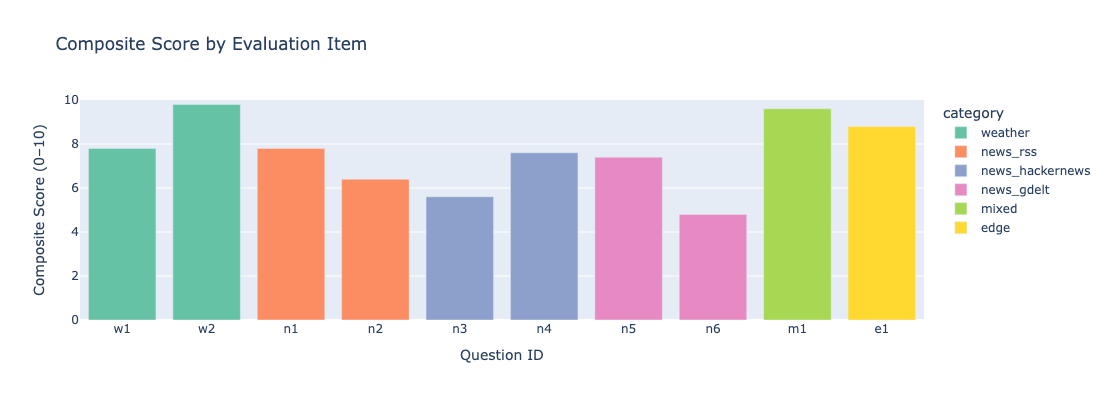

In [26]:
# ── 7.2 Bar chart: composite score by question ────────────────────────────────
fig_bar = px.bar(
    df,
    x="id",
    y="composite",
    color="category",
    title="Composite Score by Evaluation Item",
    labels={"composite": "Composite Score (0–10)", "id": "Question ID"},
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig_bar.update_layout(yaxis_range=[0, 10], height=400)
fig_bar.show()

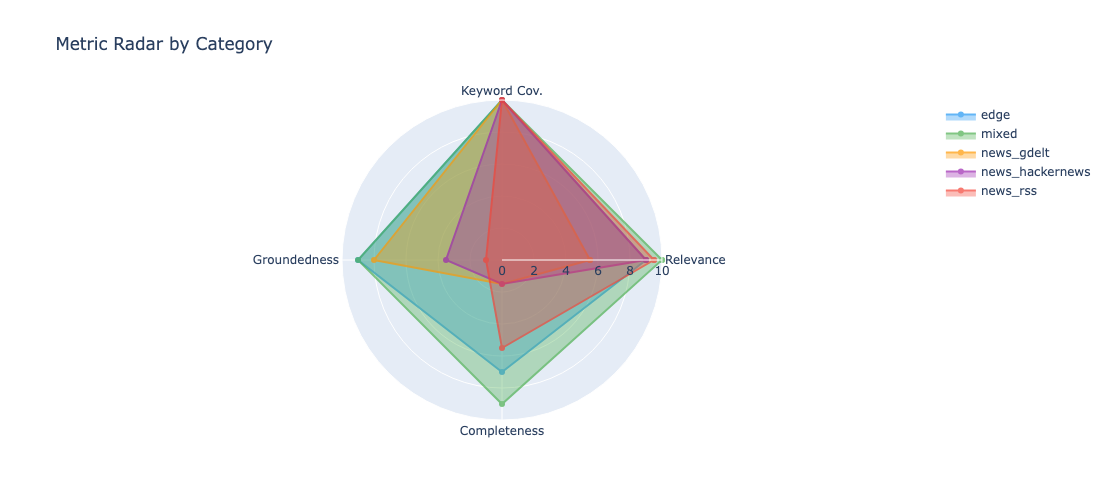

In [27]:
# ── 7.3 Radar chart: average metrics per category ────────────────────────────
cat_avg = df.groupby("category")[["relevance", "keyword", "groundedness", "completeness"]].mean()
cat_avg["keyword"] *= 10  # normalise to 0–10

metrics = ["relevance", "keyword", "groundedness", "completeness"]
metric_labels = ["Relevance", "Keyword Cov.", "Groundedness", "Completeness"]

fig_radar = go.Figure()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]

for (cat, row), color in zip(cat_avg.iterrows(), colors):
    values = row[metrics].tolist()
    fig_radar.add_trace(go.Scatterpolar(
        r=values + [values[0]],
        theta=metric_labels + [metric_labels[0]],
        fill="toself",
        name=cat,
        line_color=color,
        opacity=0.7,
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
    title="Metric Radar by Category",
    height=500,
)
fig_radar.show()

In [28]:
# ── 7.4 Summary statistics ────────────────────────────────────────────────────
print("Overall evaluation summary")
print("=" * 40)
print(f"  Mean composite score : {df['composite'].mean():.2f} / 10")
print(f"  Min composite score  : {df['composite'].min():.2f}  ({df.loc[df['composite'].idxmin(), 'id']})")
print(f"  Max composite score  : {df['composite'].max():.2f}  ({df.loc[df['composite'].idxmax(), 'id']})")
print()
print(f"  Mean relevance       : {df['relevance'].mean():.2f}")
print(f"  Mean keyword cov.    : {df['keyword'].mean():.0%}")
print(f"  Mean groundedness    : {df['groundedness'].mean():.2f}")
print(f"  Mean completeness    : {df['completeness'].mean():.2f}")

Overall evaluation summary
  Mean composite score : 7.56 / 10
  Min composite score  : 4.80  (n6)
  Max composite score  : 9.80  (w2)

  Mean relevance       : 8.70
  Mean keyword cov.    : 100%
  Mean groundedness    : 6.10
  Mean completeness    : 4.30


---
## Summary & Key Learnings <a id="8-summary"></a>

### What was implemented and demonstrated

| Component | Implementation |
|-----------|----------------|
| **Custom MCP Weather Server** | `FastMCP` server exposing `resolve_city` and `get_current_weather`; wraps Open-Meteo REST API with geocoding |
| **News MCP Integration** | Synchronous bridge to `news-aggregator-mcp-server` covering RSS (19 feeds), HackerNews, and GDELT |
| **Agentic Tool-Use Loop** | Claude claude-opus-4-6 drives a `while stop_reason == "tool_use"` loop up to 10 iterations; all 13 tools registered via JSON schema |
| **Streamlit UI** | Chat tab with conversation history + Evaluation tab with metric cards, radar chart, bar chart, and per-question expanders |
| **LLM-as-Judge Evaluation** | 4-metric framework (relevance, keyword coverage, groundedness, completeness); Claude Haiku 4.5 as judge; pass/fail per question with configurable threshold |
| **Tool-call Tracking** | Evaluator records which tools were actually called per question for debugging and analysis |

### Why this matters

- **MCP is the emerging standard** for connecting AI models to external data sources. Building a custom MCP server from scratch demonstrates how any REST API can be wrapped and exposed to an LLM as a callable tool.
- **Agentic loops require careful design.** The orchestrator must handle multi-step reasoning (e.g., geocode a city → fetch weather), error recovery, and a maximum-iteration safeguard to avoid runaway costs.
- **Evaluation is non-trivial for open-ended answers.** Using another LLM as a judge (LLM-as-judge pattern) enables scalable quality measurement without hand-labelling every response — a standard technique in production AI systems.
- **Data source diversity matters.** Combining RSS feeds, HackerNews, and GDELT gives the agent broad coverage (tech, community, global/multi-language) that no single source could provide.
- **Async-to-sync bridging** is a real engineering challenge when integrating async libraries into synchronous frameworks like Streamlit — solved here with a `ThreadPoolExecutor` fallback.

### Next steps

- **Streaming responses** — use the Anthropic streaming API so users see partial answers as they arrive rather than waiting for the full response.
- **Persistent conversation memory** — store tool results across turns so the agent can reference earlier answers without re-fetching.
- **More MCP servers** — add finance data (Yahoo Finance), weather forecasts (multi-day), or a web-search tool.
- **Automated evaluation CI** — run the evaluation suite on every code change and track metric trends over time.
- **Tool-use optimisation** — analyse `tool_calls_made` logs to identify which tools are under- or over-used and fine-tune the system prompt accordingly.
- **Multi-agent architecture** — delegate specialised sub-tasks (weather, news, summarisation) to separate agents orchestrated by a routing layer.

---

### Running the Streamlit app

```bash
export ANTHROPIC_API_KEY=sk-ant-...
streamlit run app.py
```
